# Words Test Evaluation Analysis (CNN+BiLSTM+CTC)

This notebook reproduces the test-time flow of `src/evaluation.py` and adds deeper error analysis.

It will generate:
- per-sample predictions (image path, truth, prediction, CER/WER, confidence proxy)
- CSV and Excel exports
- confusion matrix for top frequent words
- precision/recall/F1 (micro, macro, weighted)
- wrong prediction image path list
- additional diagnostics to improve accuracy, WER, and CER

## Optional Dependency Install
If imports fail, run the next line once:

`%pip install pandas matplotlib seaborn openpyxl`

In [1]:
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple
import json
import os
import sys

import numpy as np

try:
    import pandas as pd
except ImportError as exc:
    raise ImportError("pandas is required. Install with: %pip install pandas openpyxl") from exc

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError("matplotlib is required. Install with: %pip install matplotlib") from exc

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == "src" and (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"HAS_SEABORN: {HAS_SEABORN}")

PROJECT_ROOT: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR
HAS_SEABORN: True


In [2]:
from src.architecture import compile_hybrid_network
from src.config import (
    FORMS_METADATA,
    IMAGE_DIRECTORY,
    MODEL_DIRECTORY,
    RANDOM_SEED,
    SPLIT_INDEX_FILE,
    SPLIT_TEST_RATIO,
    SPLIT_TRAIN_RATIO,
    SPLIT_VAL_RATIO,
    STRICT_CHARSET_POLICY,
    STRICT_LM_DECODER,
    STRICT_SPLIT_POLICY,
    SEQUENCE_TIME_STEPS,
)
from src.dataset_parser import (
    parse_iam_metadata,
    encode_ground_truth,
    # compute_ctc_min_timesteps,
)
from src.inference_engine import build_replication_lm_decoder, execute_ctc_decoding
from src.metrics import aggregate_corpus_metrics, levenshtein_distance
from src.preprocessing import execute_morphological_preprocessing
from src.split_utils import load_or_create_split_indices

I0000 00:00:1777308209.876286    1925 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777308210.510478    1925 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1777308223.422124    1925 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
WEIGHTS_PATH = os.path.join(MODEL_DIRECTORY, "optimal_hybrid_weights.weights.h5")
REQUIRE_LM = STRICT_LM_DECODER
BATCH_SIZE = 64
TOP_CM_CLASSES = 20
MIN_CLASS_FREQ = 3

OUTPUT_DIR = PROJECT_ROOT / "src" / "analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"WEIGHTS_PATH: {WEIGHTS_PATH}")
print(f"REQUIRE_LM: {REQUIRE_LM}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

WEIGHTS_PATH: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/saved_models/optimal_hybrid_weights.weights.h5
REQUIRE_LM: True
OUTPUT_DIR: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs


In [4]:
def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator) / float(denominator) if denominator else 0.0


def compute_multiclass_metrics(y_true: List[str], y_pred: List[str]) -> Tuple[Dict[str, float], pd.DataFrame]:
    labels = sorted(set(y_true) | set(y_pred))
    support = Counter(y_true)

    tp = Counter()
    fp = Counter()
    fn = Counter()

    for truth, pred in zip(y_true, y_pred):
        if truth == pred:
            tp[truth] += 1
        else:
            fp[pred] += 1
            fn[truth] += 1

    per_label_rows = []
    for label in labels:
        tpi = tp[label]
        fpi = fp[label]
        fni = fn[label]

        precision_i = safe_div(tpi, tpi + fpi)
        recall_i = safe_div(tpi, tpi + fni)
        f1_i = safe_div(2.0 * precision_i * recall_i, precision_i + recall_i)

        per_label_rows.append(
            {
                "label": label,
                "support": int(support[label]),
                "tp": int(tpi),
                "fp": int(fpi),
                "fn": int(fni),
                "precision": precision_i,
                "recall": recall_i,
                "f1": f1_i,
            }
        )

    per_class_df = pd.DataFrame(per_label_rows)

    macro_precision = float(per_class_df["precision"].mean()) if not per_class_df.empty else 0.0
    macro_recall = float(per_class_df["recall"].mean()) if not per_class_df.empty else 0.0
    macro_f1 = float(per_class_df["f1"].mean()) if not per_class_df.empty else 0.0

    total_support = int(per_class_df["support"].sum()) if not per_class_df.empty else 0
    weighted_precision = (
        float((per_class_df["precision"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )
    weighted_recall = (
        float((per_class_df["recall"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )
    weighted_f1 = (
        float((per_class_df["f1"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )

    total = len(y_true)
    correct = sum(int(t == p) for t, p in zip(y_true, y_pred))
    micro_precision = safe_div(correct, total)
    micro_recall = safe_div(correct, total)
    micro_f1 = safe_div(correct, total)

    metric_summary = {
        "precision_micro": micro_precision,
        "recall_micro": micro_recall,
        "f1_micro": micro_f1,
        "precision_macro": macro_precision,
        "recall_macro": macro_recall,
        "f1_macro": macro_f1,
        "precision_weighted": weighted_precision,
        "recall_weighted": weighted_recall,
        "f1_weighted": weighted_f1,
    }

    return metric_summary, per_class_df


def char_alignment_ops(truth: str, pred: str):
    m, n = len(truth), len(pred)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            substitution_cost = 0 if truth[i - 1] == pred[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + substitution_cost,
            )

    i, j = m, n
    ops = []

    while i > 0 or j > 0:
        if i > 0 and j > 0:
            substitution_cost = 0 if truth[i - 1] == pred[j - 1] else 1
            if dp[i][j] == dp[i - 1][j - 1] + substitution_cost:
                if substitution_cost == 0:
                    ops.append(("match", truth[i - 1], pred[j - 1]))
                else:
                    ops.append(("sub", truth[i - 1], pred[j - 1]))
                i -= 1
                j -= 1
                continue

        if i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            ops.append(("del", truth[i - 1], ""))
            i -= 1
        else:
            ops.append(("ins", "", pred[j - 1]))
            j -= 1

    ops.reverse()
    return ops


def _diagnose_kenlm_module() -> Dict[str, object]:
    details: Dict[str, object] = {
        "import_ok": False,
        "module_file": None,
        "has_model_attr": False,
        "module_repr": None,
    }

    try:
        import kenlm

        details["import_ok"] = True
        details["module_file"] = getattr(kenlm, "__file__", None)
        details["has_model_attr"] = hasattr(kenlm, "Model")
        details["module_repr"] = repr(kenlm)
    except Exception as exc:
        details["module_repr"] = f"{type(exc).__name__}: {exc}"

    return details


def resolve_lm_decoder(require_lm: bool):
    try:
        decoder = build_replication_lm_decoder(required=require_lm)
        return decoder, require_lm, None
    except Exception as exc:
        message = f"{type(exc).__name__}: {exc}"
        lowered = message.lower()

        looks_like_lm_issue = (
            "kenlm" in lowered
            or "pyctcdecode" in lowered
            or "arpa" in lowered
            or "unigram" in lowered
        )

        if require_lm and looks_like_lm_issue:
            diag = _diagnose_kenlm_module()
            fallback_note = (
                "LM decoder unavailable, auto-falling back to CTC-only decoding. "
                f"{message} | kenlm_file={diag['module_file']} | "
                f"kenlm_has_model={diag['has_model_attr']}"
            )
            print("WARNING:", fallback_note)
            return None, False, fallback_note

        raise


def build_prediction_table(weights_path: str, require_lm: bool, batch_size: int = 64):
    corpus = parse_iam_metadata(
        FORMS_METADATA,
        IMAGE_DIRECTORY,
        strict_charset=STRICT_CHARSET_POLICY,
        strict_integrity=True,
    )

    _, _, test_idx = load_or_create_split_indices(
        total_size=len(corpus),
        split_path=SPLIT_INDEX_FILE,
        train_ratio=SPLIT_TRAIN_RATIO,
        val_ratio=SPLIT_VAL_RATIO,
        test_ratio=SPLIT_TEST_RATIO,
        seed=RANDOM_SEED,
        strict=STRICT_SPLIT_POLICY,
    )

    test_subset = [corpus[i] for i in test_idx]
    if not test_subset:
        raise RuntimeError("Test subset is empty.")

    prepared = []
    dropped_samples = 0

    for sample in test_subset:
        truth = sample["transcription"]

        try:
            encoded = encode_ground_truth(truth, strict_charset=True)
        except ValueError:
            dropped_samples += 1
            continue

        if len(encoded) == 0 or len(encoded) > SEQUENCE_TIME_STEPS:
            dropped_samples += 1
            continue

        # if compute_ctc_min_timesteps(encoded) > SEQUENCE_TIME_STEPS:
        #     dropped_samples += 1
        #     continue

        image_tensor = execute_morphological_preprocessing(sample["path"])
        if image_tensor is None:
            dropped_samples += 1
            continue

        prepared.append(
            {
                "path": sample["path"],
                "truth": truth,
                "image": image_tensor,
            }
        )

    if not prepared:
        raise RuntimeError("No evaluable samples after preprocessing.")

    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Missing model weights at {weights_path}")

    _, model_inference = compile_hybrid_network()
    model_inference.load_weights(weights_path)

    lm_decoder, decode_require_lm, decoder_fallback_note = resolve_lm_decoder(require_lm=require_lm)

    rows = []
    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        image_batch = np.asarray([sample["image"] for sample in batch], dtype=np.float32)

        probs = model_inference(image_batch, training=False)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = np.asarray(probs, dtype=np.float32)

        pred_batch = execute_ctc_decoding(
            probs,
            lm_decoder=lm_decoder,
            require_lm=decode_require_lm,
        )

        if len(pred_batch) != len(batch):
            raise RuntimeError(
                f"Prediction/metadata mismatch in batch: {len(pred_batch)} vs {len(batch)}"
            )

        for sample, pred, sample_probs in zip(batch, pred_batch, probs):
            truth = str(sample["truth"])
            pred = str(pred)

            char_edits = int(levenshtein_distance(pred, truth))
            word_edits = int(levenshtein_distance(pred.split(), truth.split()))

            max_probs = np.max(sample_probs, axis=1)
            max_probs = np.clip(max_probs, 1e-8, 1.0)

            rows.append(
                {
                    "image_path": sample["path"],
                    "image_name": Path(sample["path"]).name,
                    "word_id": Path(sample["path"]).stem,
                    "truth_word": truth,
                    "predicted_word": pred,
                    "is_correct": int(pred == truth),
                    "char_edit_distance": char_edits,
                    "word_edit_distance": word_edits,
                    "cer": safe_div(char_edits, max(len(truth), 1)),
                    "wer": safe_div(word_edits, max(len(truth.split()), 1)),
                    "truth_length": len(truth),
                    "pred_length": len(pred),
                    "length_delta": len(pred) - len(truth),
                    "ctc_confidence_meanmax": float(np.mean(max_probs)),
                    "ctc_confidence_geo": float(np.exp(np.mean(np.log(max_probs)))),
                }
            )

    result_df = pd.DataFrame(rows)

    if decode_require_lm:
        decoder_mode = "lm_ctcdecode"
    elif decoder_fallback_note:
        decoder_mode = "ctc_only_fallback"
    else:
        decoder_mode = "ctc_only"

    run_info = {
        "test_subset_size": len(test_subset),
        "evaluated_samples": len(result_df),
        "dropped_samples": dropped_samples,
        "requested_lm": bool(require_lm),
        "effective_require_lm": bool(decode_require_lm),
        "decoder_mode": decoder_mode,
        "decoder_fallback_note": decoder_fallback_note,
    }

    return result_df, run_info

In [5]:
kenlm_diag = _diagnose_kenlm_module()
print("KenLM diagnostics:")
display(pd.DataFrame([kenlm_diag]))

if REQUIRE_LM and not bool(kenlm_diag.get("has_model_attr", False)):
    print(
        "LM is requested but kenlm.Model is not available in current environment. "
        "Notebook will auto-fallback to CTC-only decoding."
    )

KenLM diagnostics:


,import_ok,module_file,has_model_attr,module_repr
0,True,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/venv/lib/python3...,True,<module 'kenlm' from '/mnt/d/HTR/CNN-BiLSTM-CT...


In [6]:
import importlib
import importlib.util
from importlib.machinery import PathFinder
import site
import subprocess
import sys


def _site_package_candidates() -> List[str]:
    candidates: List[str] = []

    try:
        candidates.extend(site.getsitepackages())
    except Exception:
        pass

    try:
        user_site = site.getusersitepackages()
        if isinstance(user_site, str):
            candidates.append(user_site)
        else:
            candidates.extend(list(user_site))
    except Exception:
        pass

    deduped: List[str] = []
    for path_str in candidates:
        if path_str and path_str not in deduped:
            deduped.append(path_str)

    return deduped


def _purge_module_cache(prefixes: List[str]) -> None:
    for module_name in list(sys.modules.keys()):
        if any(module_name == p or module_name.startswith(p + ".") for p in prefixes):
            sys.modules.pop(module_name, None)


def _import_kenlm_from_site_paths(site_paths: List[str]):
    spec = PathFinder.find_spec("kenlm", site_paths)
    if spec is None or spec.loader is None:
        return None, "No kenlm spec found on site-packages paths"

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    sys.modules["kenlm"] = module

    module_file = getattr(module, "__file__", None)
    has_model = hasattr(module, "Model")
    return module, f"Loaded kenlm from site-packages: file={module_file}, has_model={has_model}"


def _kenlm_status_snapshot() -> Dict[str, object]:
    snapshot: Dict[str, object] = {
        "python_executable": sys.executable,
        "project_root": str(PROJECT_ROOT),
        "cwd": str(Path.cwd()),
        "project_root_in_sys_path": str(PROJECT_ROOT) in sys.path,
        "local_kenlm_dir_exists": (PROJECT_ROOT / "kenlm").exists(),
        "kenlm_import_ok": False,
        "kenlm_file": None,
        "kenlm_has_model": False,
        "kenlm_repr": None,
    }

    try:
        import kenlm  # type: ignore

        snapshot["kenlm_import_ok"] = True
        snapshot["kenlm_file"] = getattr(kenlm, "__file__", None)
        snapshot["kenlm_has_model"] = hasattr(kenlm, "Model")
        snapshot["kenlm_repr"] = repr(kenlm)
    except Exception as exc:
        snapshot["kenlm_repr"] = f"{type(exc).__name__}: {exc}"

    return snapshot


def _run_pip_command(args: List[str], timeout: int = 1800) -> Dict[str, object]:
    command = [sys.executable, "-m", "pip"] + args

    try:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=timeout,
            check=False,
        )
        stdout_tail = "\n".join(completed.stdout.splitlines()[-25:])
        stderr_tail = "\n".join(completed.stderr.splitlines()[-25:])
        return {
            "command": " ".join(command),
            "returncode": completed.returncode,
            "stdout_tail": stdout_tail,
            "stderr_tail": stderr_tail,
        }
    except Exception as exc:
        return {
            "command": " ".join(command),
            "returncode": -1,
            "stdout_tail": "",
            "stderr_tail": f"{type(exc).__name__}: {exc}",
        }


def repair_lm_environment(
    try_install_if_needed: bool = True,
    prefer_local_kenlm_source: bool = True,
) -> Tuple[Dict[str, object], List[Dict[str, object]]]:
    site_paths = _site_package_candidates()
    actions: List[str] = []

    before = _kenlm_status_snapshot()
    actions.append(
        f"Before repair: kenlm_file={before['kenlm_file']}, kenlm_has_model={before['kenlm_has_model']}"
    )

    # Put site-packages ahead of project root path and keep project root at the end.
    for sp in reversed(site_paths):
        if sp in sys.path:
            sys.path.remove(sp)
        sys.path.insert(0, sp)

    project_root_str = str(PROJECT_ROOT)
    if project_root_str in sys.path:
        while project_root_str in sys.path:
            sys.path.remove(project_root_str)
        sys.path.append(project_root_str)
        actions.append("Moved PROJECT_ROOT to end of sys.path")

    _purge_module_cache(["kenlm", "pyctcdecode", "src.inference_engine"])

    # First try: force import kenlm only from site-packages.
    forced_module, forced_message = _import_kenlm_from_site_paths(site_paths)
    actions.append(forced_message)

    install_logs: List[Dict[str, object]] = []
    install_attempted = False

    has_model_now = forced_module is not None and hasattr(forced_module, "Model")
    if not has_model_now and try_install_if_needed:
        install_attempted = True

        # Ensure decoder side is available/up-to-date.
        install_logs.append(_run_pip_command(["install", "--upgrade", "pyctcdecode"]))

        local_kenlm = PROJECT_ROOT / "kenlm"
        if prefer_local_kenlm_source and local_kenlm.exists():
            install_logs.append(_run_pip_command(["install", "-e", str(local_kenlm)]))
            actions.append("Attempted kenlm install from local source folder")
        else:
            install_logs.append(_run_pip_command(["install", "--upgrade", "kenlm"]))
            actions.append("Attempted kenlm install from pip package")

        _purge_module_cache(["kenlm", "pyctcdecode", "src.inference_engine"])
        forced_module, forced_message = _import_kenlm_from_site_paths(site_paths)
        actions.append("Post-install import check: " + forced_message)

    final_has_model = forced_module is not None and hasattr(forced_module, "Model")

    decoder_build_ok = False
    decoder_error = None

    if final_has_model:
        try:
            import src.inference_engine as _inference_engine

            _inference_engine = importlib.reload(_inference_engine)

            globals()["build_replication_lm_decoder"] = _inference_engine.build_replication_lm_decoder
            globals()["execute_ctc_decoding"] = _inference_engine.execute_ctc_decoding

            globals()["REQUIRE_LM"] = True

            decoder_obj = build_replication_lm_decoder(required=True)
            decoder_build_ok = decoder_obj is not None
            actions.append("Decoder build test succeeded with required=True")
        except Exception as exc:
            decoder_error = f"{type(exc).__name__}: {exc}"
            actions.append("Decoder build test failed")

    after = _kenlm_status_snapshot()

    result = {
        "python_executable": sys.executable,
        "site_paths_count": len(site_paths),
        "before_kenlm_file": before["kenlm_file"],
        "before_kenlm_has_model": before["kenlm_has_model"],
        "after_kenlm_file": after["kenlm_file"],
        "after_kenlm_has_model": after["kenlm_has_model"],
        "install_attempted": install_attempted,
        "decoder_build_ok": decoder_build_ok,
        "decoder_error": decoder_error,
        "actions": " | ".join(actions),
    }

    return result, install_logs


TRY_INSTALL_IF_NEEDED = True
PREFER_LOCAL_KENLM_SOURCE = True

lm_repair_result, lm_install_logs = repair_lm_environment(
    try_install_if_needed=TRY_INSTALL_IF_NEEDED,
    prefer_local_kenlm_source=PREFER_LOCAL_KENLM_SOURCE,
)

print("LM repair result:")
display(pd.DataFrame([lm_repair_result]))

if lm_install_logs:
    print("\nInstall command logs (tail):")
    display(pd.DataFrame(lm_install_logs))

if not bool(lm_repair_result["after_kenlm_has_model"]):
    print(
        "\nLM still unavailable. Keep fallback enabled, or re-run this cell after ensuring build tools "
        "(CMake + C++ compiler) are installed for local kenlm build."
    )
else:
    print("\nLM looks healthy now. Re-run the evaluation cell (the next code cell) for real LM decoding.")

LM repair result:


,python_executable,site_paths_count,before_kenlm_file,before_kenlm_has_model,after_kenlm_file,after_kenlm_has_model,install_attempted,decoder_build_ok,decoder_error,actions
0,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/venv/bin/python3,5,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/venv/lib/python3...,True,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/venv/lib/python3...,True,False,True,None,Before repair: kenlm_file=/mnt/d/HTR/CNN-BiLST...



LM looks healthy now. Re-run the evaluation cell (the next code cell) for real LM decoding.


In [7]:
predictions_df, run_info = build_prediction_table(
    weights_path=WEIGHTS_PATH,
    require_lm=REQUIRE_LM,
    batch_size=BATCH_SIZE,
)

truth_series = predictions_df["truth_word"].astype(str)
pred_series = predictions_df["predicted_word"].astype(str)

# Case-insensitive correctness for accuracy reporting.
truth_ci_series = truth_series.str.casefold()
pred_ci_series = pred_series.str.casefold()
predictions_df["is_correct"] = (truth_ci_series == pred_ci_series).astype(int)

truths = truth_series.tolist()
preds = pred_series.tolist()
truths_ci = truth_ci_series.tolist()
preds_ci = pred_ci_series.tolist()

# Compute accuracy-oriented metrics in case-insensitive mode.
core_metrics = aggregate_corpus_metrics(preds_ci, truths_ci)
cls_metrics, per_class_df = compute_multiclass_metrics(truths_ci, preds_ci)

overall_accuracy_pct = 100.0 * float(predictions_df["is_correct"].mean())
case_only_match_count = int(((truth_series != pred_series) & (truth_ci_series == pred_ci_series)).sum())

summary = {
    "evaluated_samples": int(len(predictions_df)),
    "accuracy_mode": "case_insensitive",
    "case_only_matches_treated_correct": case_only_match_count,
    "exact_match_accuracy_pct": overall_accuracy_pct,
    "sequence_accuracy_pct": float(core_metrics["sequence_accuracy"]),
    "word_accuracy_pct": float(core_metrics["word_accuracy"]),
    "character_accuracy_pct": float(core_metrics["character_accuracy"]),
    "wer_avg": float(core_metrics["wer"]),
    "cer_avg": float(core_metrics["cer"]),
    "wer_global": float(core_metrics["global_wer"]),
    "cer_global": float(core_metrics["global_cer"]),
    "precision_micro": float(cls_metrics["precision_micro"]),
    "recall_micro": float(cls_metrics["recall_micro"]),
    "f1_micro": float(cls_metrics["f1_micro"]),
    "precision_macro": float(cls_metrics["precision_macro"]),
    "recall_macro": float(cls_metrics["recall_macro"]),
    "f1_macro": float(cls_metrics["f1_macro"]),
    "precision_weighted": float(cls_metrics["precision_weighted"]),
    "recall_weighted": float(cls_metrics["recall_weighted"]),
    "f1_weighted": float(cls_metrics["f1_weighted"]),
}

summary_df = pd.DataFrame([summary]).T.reset_index()
summary_df.columns = ["metric", "value"]

print("Run info:", run_info)
display(summary_df)
display(predictions_df.head(10))

2026-04-27 16:45:43,110 - src.dataset_parser - [INFO] - Word metadata ingestion complete. Total verified samples: 96456


I0000 00:00:1777308559.221429    1925 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


2026-04-27 16:49:21,048 - src.architecture - [INFO] - CNN-BiLSTM-CTC architecture compiled. Spatial tensor constrained to (32, 256).


I0000 00:00:1777308561.361298    1925 cuda_dnn.cc:461] Loaded cuDNN version 92101


2026-04-27 16:49:53,021 - src.metrics - [INFO] - SeqAcc: 87.37% | WordAcc: 87.35% | CharAcc: 94.59% | WER(avg): 0.1264 | CER(avg): 0.0597 | WER(global): 0.1265 | CER(global): 0.0541


Run info: {'test_subset_size': 19292, 'evaluated_samples': 19292, 'dropped_samples': 0, 'requested_lm': True, 'effective_require_lm': True, 'decoder_mode': 'lm_ctcdecode', 'decoder_fallback_note': None}


,metric,value
0,evaluated_samples,19292
1,accuracy_mode,case_insensitive
2,case_only_matches_treated_correct,147
3,exact_match_accuracy_pct,87.373004
4,sequence_accuracy_pct,87.373004
5,word_accuracy_pct,87.351021
6,character_accuracy_pct,94.592985
7,wer_avg,0.1264
8,cer_avg,0.059737
9,wer_global,0.12649


,image_path,image_name,word_id,truth_word,predicted_word,is_correct,char_edit_distance,word_edit_distance,cer,wer,truth_length,pred_length,length_delta,ctc_confidence_meanmax,ctc_confidence_geo
0,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/g07/g...,g07-038-08-06.png,g07-038-08-06,implicitly,umplicitly,0,1,1,0.100000,1.0,10,10,0,0.952044,0.943938
1,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/m03/m...,m03-020-05-08.png,m03-020-05-08,.,.,1,0,0,0.000000,0.0,1,1,0,0.999432,0.999428
2,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/k04/k...,k04-028-06-03.png,k04-028-06-03,deal,deal,1,0,0,0.000000,0.0,4,4,0,0.999089,0.999086
3,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/p01/p...,p01-168-02-00.png,p01-168-02-00,been,been,1,0,0,0.000000,0.0,4,4,0,0.996994,0.996902
4,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/n04/n...,n04-218-09-00.png,n04-218-09-00,suitable,suitable,1,0,0,0.000000,0.0,8,8,0,0.980759,0.977176
5,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/n04/n...,n04-171-02-10.png,n04-171-02-10,made,made,1,0,0,0.000000,0.0,4,4,0,0.990038,0.988925
6,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/r02/r...,r02-013-03-06.png,r02-013-03-06,recol-,sent,0,5,1,0.833333,1.0,6,4,-2,0.919615,0.897995
7,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/n02/n...,n02-000-03-07.png,n02-000-03-07,quickly,quickly,1,0,0,0.000000,0.0,7,7,0,0.981636,0.978053
8,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/n04/n...,n04-218-04-04.png,n04-218-04-04,happened,happened,1,0,0,0.000000,0.0,8,8,0,0.955861,0.944108
9,/mnt/d/HTR/CNN-BiLSTM-CTC-HTR/data/words/g01/g...,g01-039-00-03.png,g01-039-00-03,classes,classes,1,0,0,0.000000,0.0,7,7,0,0.943621,0.931662


In [8]:
timestamp = pd.Timestamp.now(tz="UTC").strftime("%Y%m%d_%H%M%S")
artifact_prefix = f"words_test_eval_{timestamp}"

full_csv_path = OUTPUT_DIR / f"{artifact_prefix}_predictions.csv"
wrong_csv_path = OUTPUT_DIR / f"{artifact_prefix}_wrong_predictions.csv"
wrong_paths_txt_path = OUTPUT_DIR / f"{artifact_prefix}_wrong_image_paths.txt"
metrics_json_path = OUTPUT_DIR / f"{artifact_prefix}_metrics.json"
excel_path = OUTPUT_DIR / f"{artifact_prefix}_predictions.xlsx"

predictions_df.to_csv(full_csv_path, index=False, encoding="utf-8")

wrong_df = predictions_df[predictions_df["is_correct"] == 0].copy()
wrong_df.to_csv(wrong_csv_path, index=False, encoding="utf-8")
wrong_df["image_path"].to_csv(wrong_paths_txt_path, index=False, header=False, encoding="utf-8")

with open(metrics_json_path, "w", encoding="utf-8") as file_buffer:
    json.dump(
        {
            "run_info": run_info,
            "summary": summary,
            "core_metrics": core_metrics,
            "classification_metrics": cls_metrics,
        },
        file_buffer,
        indent=2,
    )

excel_status = "not_attempted"
try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        predictions_df.to_excel(writer, sheet_name="all_predictions", index=False)
        wrong_df.to_excel(writer, sheet_name="wrong_predictions", index=False)
        pd.DataFrame([summary]).to_excel(writer, sheet_name="summary", index=False)
        per_class_df.sort_values("support", ascending=False).head(2000).to_excel(
            writer,
            sheet_name="per_class_top",
            index=False,
        )
    excel_status = f"saved: {excel_path}"
except Exception as exc:
    excel_status = f"skipped ({type(exc).__name__}: {exc})"

print(f"Saved full CSV: {full_csv_path}")
print(f"Saved wrong CSV: {wrong_csv_path}")
print(f"Saved wrong image paths: {wrong_paths_txt_path}")
print(f"Saved metrics JSON: {metrics_json_path}")
print(f"Excel status: {excel_status}")
print(f"Wrong predictions count: {len(wrong_df)}")

Saved full CSV: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_predictions.csv
Saved wrong CSV: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_wrong_predictions.csv
Saved wrong image paths: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_wrong_image_paths.txt
Saved metrics JSON: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_metrics.json
Excel status: saved: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_predictions.xlsx
Wrong predictions count: 2436


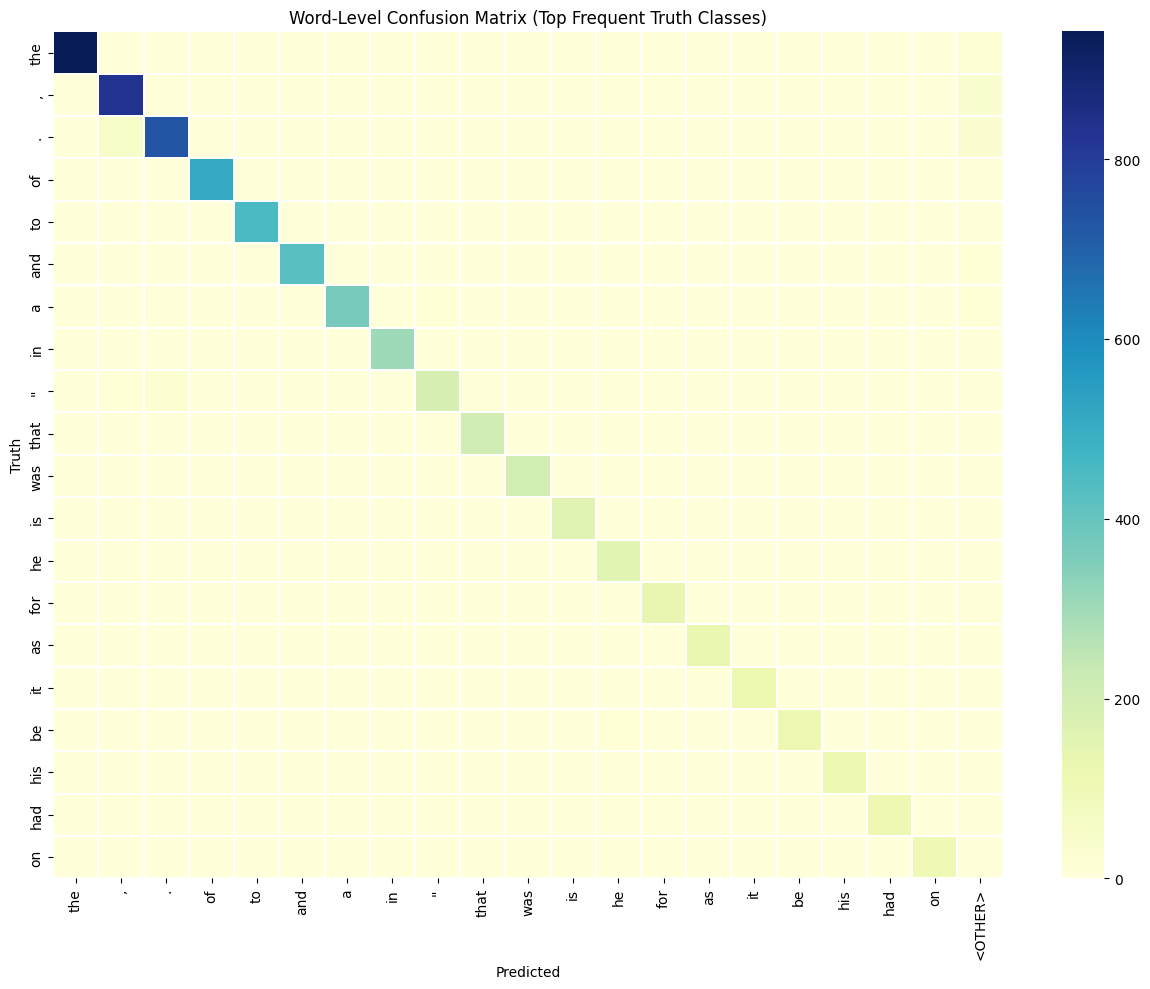

Saved confusion matrix CSV: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_word_confusion_matrix.csv
Saved confusion matrix image: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_word_confusion_matrix.png


pred_for_cm,the,",",.,of,to,and,a,in,"""",that,...,is,he,for,as,it,be,his,had,on,<OTHER>
truth_word,,,,,,,,,,,,,,,,,,,,,
the,942,0,1,1,1,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,18
",",0,833,6,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,34
.,0,51,730,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,26
of,0,0,1,512,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
to,0,0,0,1,451,0,1,0,0,0,...,0,0,2,0,0,1,0,0,0,7
and,0,0,0,0,0,426,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10
a,0,0,4,0,0,0,367,0,10,0,...,0,0,0,0,0,0,0,0,0,9
in,0,0,0,0,0,0,0,303,0,0,...,3,0,0,0,1,0,0,0,0,1
"""",0,8,25,0,0,0,1,1,187,0,...,0,0,0,0,0,0,0,0,0,7


In [9]:
artifact_prefix = globals().get("artifact_prefix", f"words_test_eval_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}")

truth_counts = predictions_df["truth_word"].value_counts()
focus_labels = truth_counts[truth_counts >= MIN_CLASS_FREQ].head(TOP_CM_CLASSES).index.tolist()

if len(focus_labels) == 0:
    print("No classes meet MIN_CLASS_FREQ. Lower MIN_CLASS_FREQ to build confusion matrix.")
else:
    cm_source = predictions_df[predictions_df["truth_word"].isin(focus_labels)].copy()
    cm_source["pred_for_cm"] = np.where(
        cm_source["predicted_word"].isin(focus_labels),
        cm_source["predicted_word"],
        "<OTHER>",
    )

    cm_df = pd.crosstab(cm_source["truth_word"], cm_source["pred_for_cm"])

    desired_cols = focus_labels + (["<OTHER>"] if "<OTHER>" in cm_df.columns else [])
    for col in desired_cols:
        if col not in cm_df.columns:
            cm_df[col] = 0

    cm_df = cm_df.reindex(index=focus_labels, columns=desired_cols, fill_value=0)

    cm_csv_path = OUTPUT_DIR / f"{artifact_prefix}_word_confusion_matrix.csv"
    cm_png_path = OUTPUT_DIR / f"{artifact_prefix}_word_confusion_matrix.png"

    cm_df.to_csv(cm_csv_path, encoding="utf-8")

    plt.figure(figsize=(max(10, len(cm_df.columns) * 0.6), max(6, len(cm_df.index) * 0.5)))
    if HAS_SEABORN:
        sns.heatmap(cm_df, annot=False, cmap="YlGnBu", linewidths=0.2)
    else:
        plt.imshow(cm_df.values, aspect="auto", cmap="YlGnBu")
        plt.xticks(range(len(cm_df.columns)), cm_df.columns.tolist(), rotation=90)
        plt.yticks(range(len(cm_df.index)), cm_df.index.tolist())
        plt.colorbar(label="Count")

    plt.title("Word-Level Confusion Matrix (Top Frequent Truth Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.tight_layout()
    plt.savefig(cm_png_path, dpi=180)
    plt.show()

    print(f"Saved confusion matrix CSV: {cm_csv_path}")
    print(f"Saved confusion matrix image: {cm_png_path}")
    display(cm_df.head(10))

Saved substitutions: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_char_substitutions.csv
Saved insertions: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_char_insertions.csv
Saved deletions: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_char_deletions.csv
Saved length-wise metrics: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_lengthwise_metrics.csv
Saved hard truth words: /mnt/d/HTR/CNN-BiLSTM-CTC-HTR/src/analysis_outputs/words_test_eval_20260427_164953_hard_truth_words.csv

Top character substitutions:


,truth_char,pred_char,count
99,a,o,98
12,',",",91
5,o,a,87
19,s,r,58
131,t,l,52
24,e,a,52
7,.,",",52
10,m,n,51
47,r,n,49
90,e,o,46



Top inserted characters:


,inserted_char,count
2,e,43
4,r,29
12,s,28
6,t,27
3,c,22
5,o,20
11,l,20
9,i,17
7,a,15
0,n,13



Top deleted characters:


,deleted_char,count
5,r,111
3,e,109
4,s,89
0,c,76
1,o,72
2,t,67
6,l,52
10,a,40
17,n,38
26,i,32


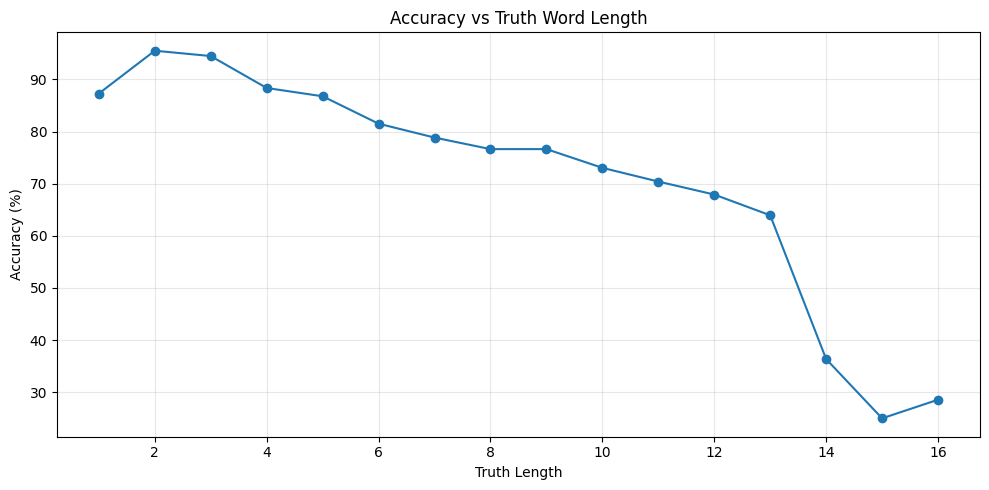

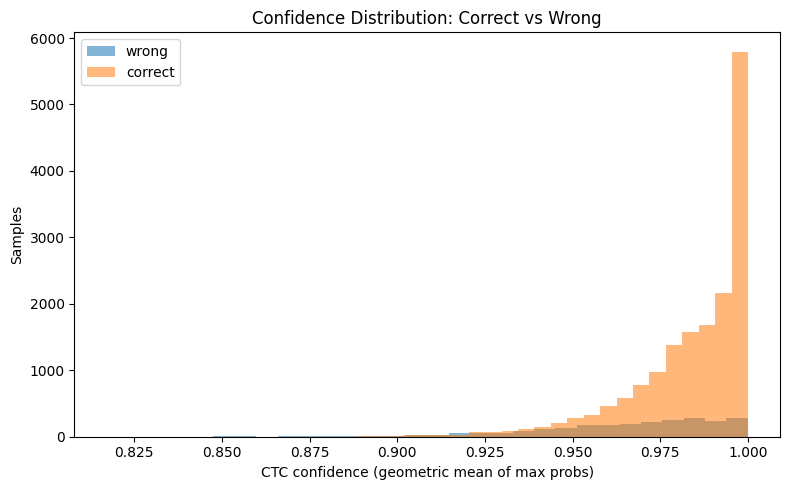


Actionable recommendations:
1. WER is relatively high: improve language model coverage (unigrams/corpus cleanup) and retune LM alpha/beta.
2. Several frequent truth words have high error rates: add targeted augmentation and hard-example replay for those tokens.
3. Model confidence is high despite errors: calibrate decoder and inspect label noise or lexicon mismatch.

Most difficult truth words (min 5 samples):


,samples,errors,error_rate
truth_word,,,
',110,103,0.936364
Secretary,8,6,0.750000
#,15,11,0.733333
children,5,3,0.600000
leaving,5,3,0.600000
physical,5,3,0.600000
Naples,10,5,0.500000
am,6,3,0.500000
),19,9,0.473684


In [10]:
artifact_prefix = globals().get("artifact_prefix", f"words_test_eval_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}")

sub_counter = Counter()
ins_counter = Counter()
del_counter = Counter()

for row in wrong_df.itertuples(index=False):
    truth = str(row.truth_word)
    pred = str(row.predicted_word)
    for op, t_char, p_char in char_alignment_ops(truth, pred):
        if op == "sub":
            sub_counter[(t_char, p_char)] += 1
        elif op == "ins":
            ins_counter[p_char] += 1
        elif op == "del":
            del_counter[t_char] += 1

top_sub_df = pd.DataFrame(
    [
        {"truth_char": t, "pred_char": p, "count": c}
        for (t, p), c in sub_counter.items()
    ]
).sort_values("count", ascending=False) if sub_counter else pd.DataFrame(columns=["truth_char", "pred_char", "count"])

top_ins_df = pd.DataFrame(
    [{"inserted_char": ch, "count": c} for ch, c in ins_counter.items()]
).sort_values("count", ascending=False) if ins_counter else pd.DataFrame(columns=["inserted_char", "count"])

top_del_df = pd.DataFrame(
    [{"deleted_char": ch, "count": c} for ch, c in del_counter.items()]
).sort_values("count", ascending=False) if del_counter else pd.DataFrame(columns=["deleted_char", "count"])

length_df = predictions_df.groupby("truth_length", as_index=False).agg(
    samples=("is_correct", "size"),
    accuracy=("is_correct", "mean"),
    avg_cer=("cer", "mean"),
    avg_wer=("wer", "mean"),
)
length_df["accuracy_pct"] = 100.0 * length_df["accuracy"]

truth_count_df = predictions_df.groupby("truth_word").size().rename("samples").to_frame()
truth_count_df["errors"] = wrong_df.groupby("truth_word").size()
truth_count_df = truth_count_df.fillna(0).astype(int)
truth_count_df["error_rate"] = truth_count_df["errors"] / truth_count_df["samples"]
hard_words_df = truth_count_df.sort_values(["error_rate", "samples"], ascending=[False, False])

sub_csv = OUTPUT_DIR / f"{artifact_prefix}_char_substitutions.csv"
ins_csv = OUTPUT_DIR / f"{artifact_prefix}_char_insertions.csv"
del_csv = OUTPUT_DIR / f"{artifact_prefix}_char_deletions.csv"
len_csv = OUTPUT_DIR / f"{artifact_prefix}_lengthwise_metrics.csv"
hard_csv = OUTPUT_DIR / f"{artifact_prefix}_hard_truth_words.csv"

top_sub_df.to_csv(sub_csv, index=False, encoding="utf-8")
top_ins_df.to_csv(ins_csv, index=False, encoding="utf-8")
top_del_df.to_csv(del_csv, index=False, encoding="utf-8")
length_df.to_csv(len_csv, index=False, encoding="utf-8")
hard_words_df.reset_index().rename(columns={"index": "truth_word"}).to_csv(hard_csv, index=False, encoding="utf-8")

print(f"Saved substitutions: {sub_csv}")
print(f"Saved insertions: {ins_csv}")
print(f"Saved deletions: {del_csv}")
print(f"Saved length-wise metrics: {len_csv}")
print(f"Saved hard truth words: {hard_csv}")

print("\nTop character substitutions:")
display(top_sub_df.head(20))
print("\nTop inserted characters:")
display(top_ins_df.head(20))
print("\nTop deleted characters:")
display(top_del_df.head(20))

plt.figure(figsize=(10, 5))
plt.plot(length_df["truth_length"], length_df["accuracy_pct"], marker="o")
plt.title("Accuracy vs Truth Word Length")
plt.xlabel("Truth Length")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for is_correct_value, group_df in predictions_df.groupby("is_correct"):
    label = "correct" if int(is_correct_value) == 1 else "wrong"
    plt.hist(group_df["ctc_confidence_geo"], bins=30, alpha=0.55, label=label)
plt.title("Confidence Distribution: Correct vs Wrong")
plt.xlabel("CTC confidence (geometric mean of max probs)")
plt.ylabel("Samples")
plt.legend()
plt.tight_layout()
plt.show()

recommendations = []

if summary["cer_avg"] > 0.12:
    recommendations.append("CER is relatively high: prioritize character-level augmentation (blur/noise/slant) and tune preprocessing thresholds.")
if summary["wer_avg"] > 0.12:
    recommendations.append("WER is relatively high: improve language model coverage (unigrams/corpus cleanup) and retune LM alpha/beta.")

total_sub = int(sum(sub_counter.values()))
total_ins = int(sum(ins_counter.values()))
total_del = int(sum(del_counter.values()))

if total_ins > max(total_del, total_sub):
    recommendations.append("Insertions dominate errors: reduce beam width or LM beta, and inspect over-segmentation artifacts.")
if total_del > max(total_ins, total_sub):
    recommendations.append("Deletions dominate errors: consider stronger image contrast normalization and slightly larger decode beam width.")

if not wrong_df.empty:
    hard_bucket = hard_words_df[(hard_words_df["samples"] >= 5) & (hard_words_df["error_rate"] >= 0.4)]
    if not hard_bucket.empty:
        recommendations.append("Several frequent truth words have high error rates: add targeted augmentation and hard-example replay for those tokens.")

if predictions_df["ctc_confidence_geo"].median() > 0.90 and summary["exact_match_accuracy_pct"] < 95:
    recommendations.append("Model confidence is high despite errors: calibrate decoder and inspect label noise or lexicon mismatch.")

if not recommendations:
    recommendations.append("Current metrics look stable. Next focus: evaluate with external test handwriting styles and perform LM/grid-search tuning.")

print("\nActionable recommendations:")
for idx, rec in enumerate(recommendations, start=1):
    print(f"{idx}. {rec}")

print("\nMost difficult truth words (min 5 samples):")
display(hard_words_df[hard_words_df["samples"] >= 5].head(20))

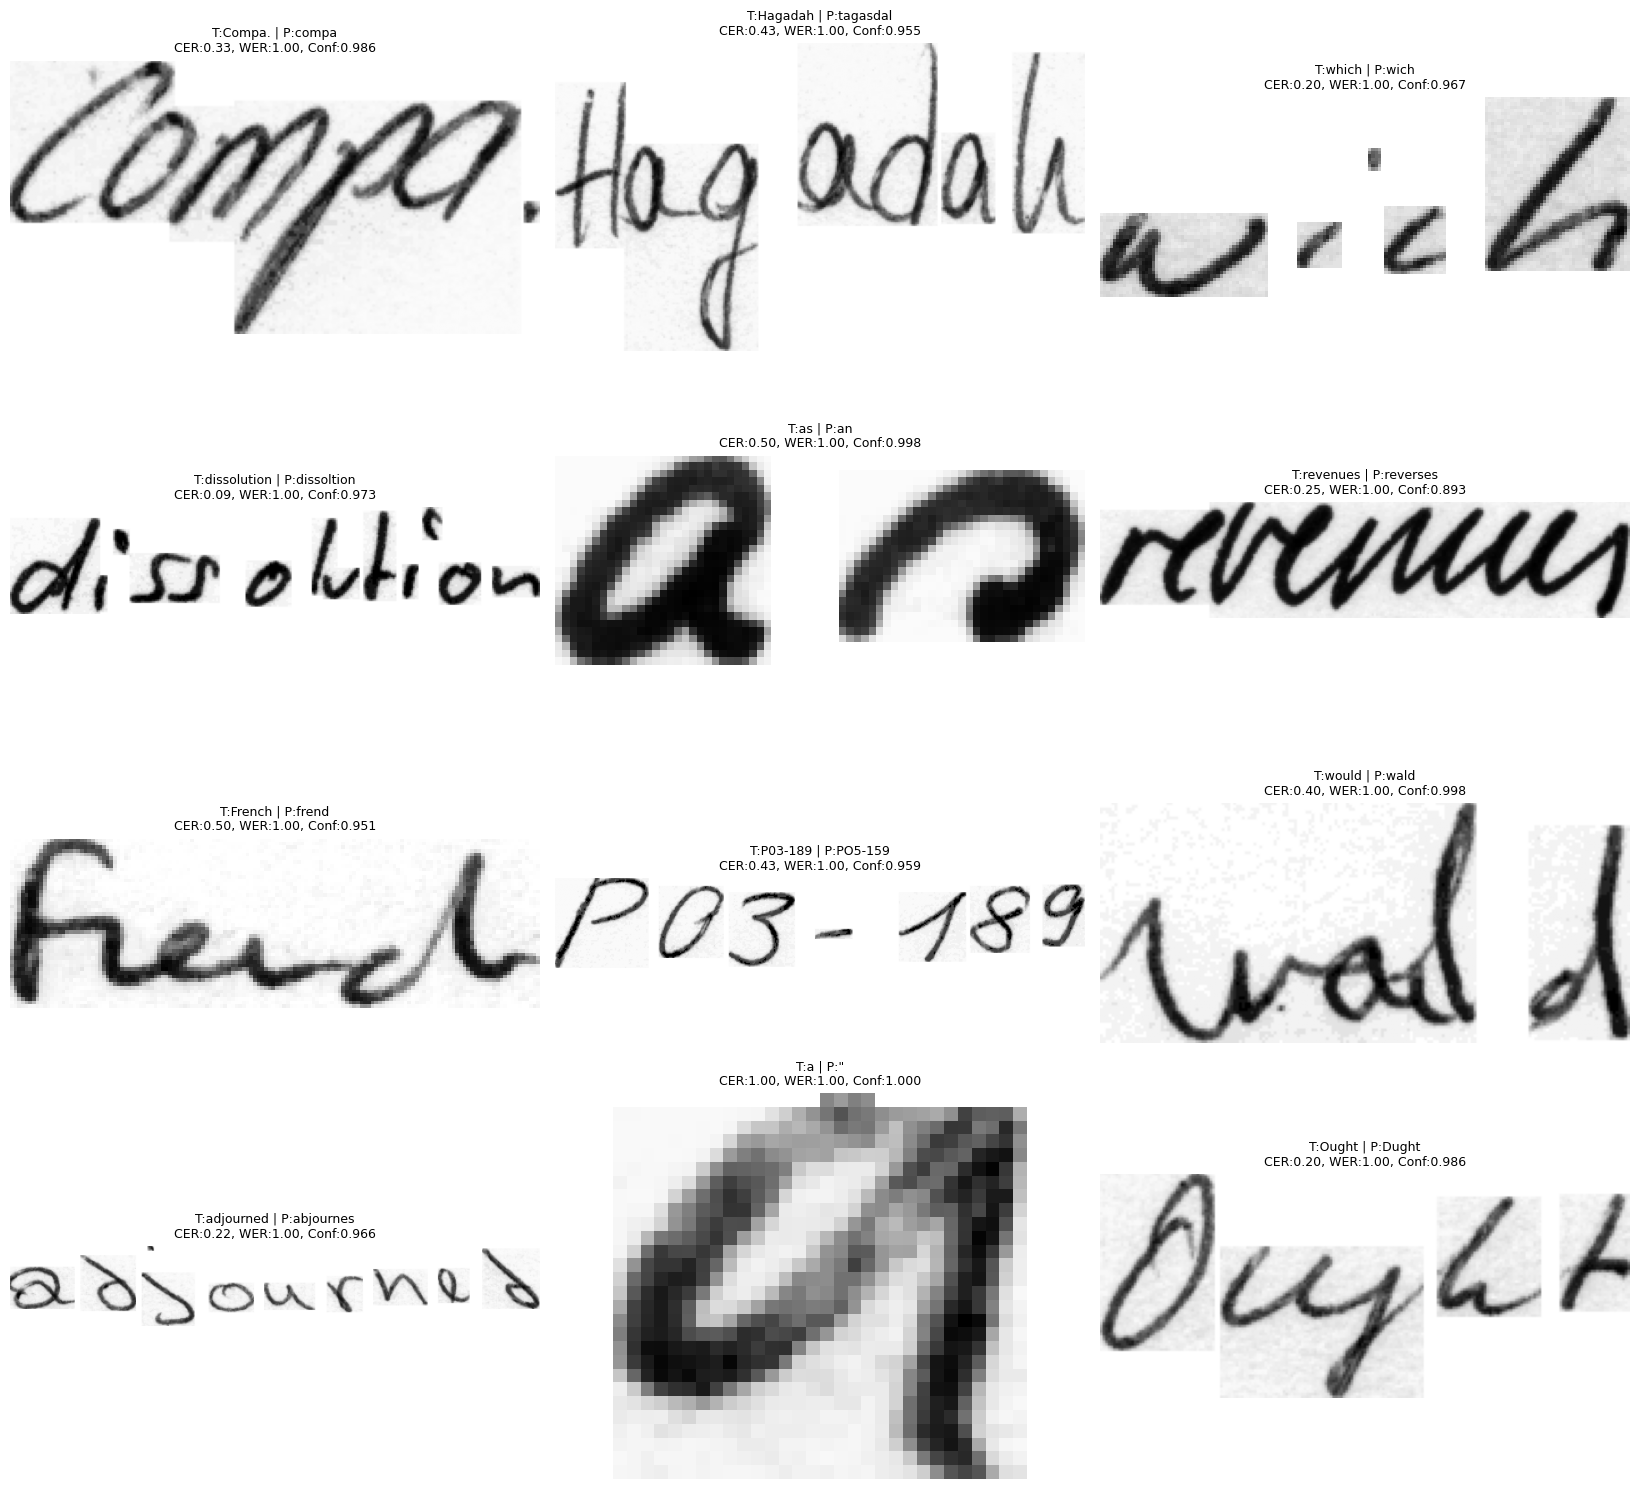

In [11]:
import cv2


def show_wrong_examples(df_wrong: pd.DataFrame, n: int = 12, seed: int = 52) -> None:
    if df_wrong.empty:
        print("No wrong predictions to visualize.")
        return

    sample_df = df_wrong.sample(n=min(n, len(df_wrong)), random_state=seed)

    cols = 3
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(5.5 * cols, 3.8 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)

        plt.subplot(rows, cols, i)
        if img is not None:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(np.zeros((32, 128), dtype=np.float32), cmap="gray")

        plt.axis("off")
        plt.title(
            f"T:{row['truth_word']} | P:{row['predicted_word']}\n"
            f"CER:{row['cer']:.2f}, WER:{row['wer']:.2f}, Conf:{row['ctc_confidence_geo']:.3f}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


show_wrong_examples(wrong_df, n=12)